# Benchmark Notebook

This notebook is a demonstration of the benchmarking for HAR models trained and validated on the Capture-24 dataset.

In [1]:
# Import relevant packages and local functions
import numpy as np
import os
import pandas as pd

from prepare_data import download_capture24, load_all_and_make_windows
from benchmark import train_test_split
from classifier import Classifier
from eval import metrics_report, performance_table

# Set import constant values
N_JOBS = 2

We must first download the dataset, to an appropriate local folder. 
These needs to be done only once but can take some time. 
After this, the downloaded folder is extracted, and prepared into data usable for this analysis.
Within this preparation, we:
1. Divide it into winsec (set to 10 seconds) windows
1. Extract annotations based on the most frequent labelled activity in the window
1. Translate raw annotation into desired labels, using the appropriate column in the annotation dictionary

In [2]:
# Download and extract Capture-24 data
# download_capture24('data')

# Prepare data for HAR classifier
load_all_and_make_windows('data', ['Walmsley2020', 'WillettsSpecific2018'], 'prepared_data', N_JOBS, winsec=10)

Using files saved at "prepared_data".


In [3]:
# Load all prepared datasets, note here we use Walmsley labels
X = np.load('prepared_data/X.npy')
Y = np.load('prepared_data/Y_Walmsley2020.npy')
T = np.load('prepared_data/T.npy')
P = np.load('prepared_data/P.npy')
X_feats = pd.read_pickle('prepared_data/X_feats.pkl').values

For the evalution of performance of each model, we train on the first 101 participants, and evaluate on the last 50.

We can make various different classifiers with different window classifier and smoothers, based on the model type string.

Note: these models are all loaded with default parameters.

In [4]:
# Splitting of train and test based on participant id
train_ids, test_ids = train_test_split(P)

X_train, y_train, P_train = X_feats[train_ids], Y[train_ids], P[train_ids]
X_test, y_test, P_test = X_feats[test_ids], Y[test_ids], P[test_ids]

In [5]:
rf_model = Classifier('rf', verbose=1)
rf_hmm_model = Classifier('rf_hmm', verbose=1)
xgb_model = Classifier('xgb')
xgb_hmm_model = Classifier('xgb_hmm')

In [6]:
rf_model.fit(X_train, y_train, P_train)
y_pred_rf = rf_model.predict(X_test, P_test)

# Here we choose to visualise a more in depth report of this model's performance
performance_rf = metrics_report(y_test, y_pred_rf, tag='Random Forest, no smoothing', n_jobs=N_JOBS)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   13.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:  2.8min
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:  4.6min
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:  6.8min
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  9.5min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed: 12.6min
[Parallel(n_jobs=12)]: Done 3000 out of 3000 | elapsed: 15.5min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.5s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    6.3s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   11.7s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   19.6s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   29.6s
[Parallel(n_job


========================= Random Forest, no smoothing =========================
                   precision    recall  f1-score   support

            light       0.61      0.66      0.64     64484
moderate-vigorous       0.53      0.63      0.58     18376
        sedentary       0.78      0.68      0.72    115213
            sleep       0.86      0.91      0.89    110375

         accuracy                           0.76    308448
        macro avg       0.70      0.72      0.71    308448
     weighted avg       0.76      0.76      0.76    308448

 Random Forest, no smoothing/bacc: 0.721 (0.719, 0.723)
   Random Forest, no smoothing/f1: 0.706 (0.704, 0.708)
  Random Forest, no smoothing/phi: 0.648 (0.646, 0.650)
Random Forest, no smoothing/kappa: 0.646 (0.645, 0.649)


In [7]:
rf_hmm_model.fit(X_train, y_train, P_train)
y_pred_rf_hmm = rf_hmm_model.predict(X_test, P_test)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    9.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   55.4s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:  2.2min
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:  4.0min
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:  6.4min
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  9.2min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed: 12.8min
[Parallel(n_jobs=12)]: Done 3000 out of 3000 | elapsed: 15.7min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.2s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    9.7s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   17.6s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   29.6s
[Parallel(n_job

In [8]:
xgb_model.fit(X_train, y_train, P_train)
y_pred_xgb = xgb_model.predict(X_test, P_test)

In [9]:
xgb_hmm_model.fit(X_train, y_train, P_train)
y_pred_xgb_hmm = xgb_hmm_model.predict(X_test, P_test)

In [10]:
performance_table(y_test, {'Random Forest': y_pred_rf,
                           'XGBoost': y_pred_xgb,
                           'Random Forest + HMM': y_pred_rf_hmm,
                           'XGBoost + HMM': y_pred_xgb_hmm}, P_test, 
                           "Walmsley's labels (Sleep, Sedentary, Light and MVPA)", n_jobs = N_JOBS)

,Balanced Accuracy,Macro F1,Matthews Correlation Coefficient,Cohen's kappa score
Random Forest,"0.721 (0.693, 0.744)","0.706 (0.687, 0.727)","0.648 (0.628, 0.667)","0.646 (0.626, 0.666)"
XGBoost,"0.672 (0.643, 0.694)","0.694 (0.668, 0.719)","0.650 (0.627, 0.669)","0.649 (0.626, 0.669)"
Random Forest + HMM,"0.812 (0.775, 0.842)","0.812 (0.783, 0.842)","0.797 (0.764, 0.826)","0.796 (0.762, 0.825)"
XGBoost + HMM,"0.798 (0.763, 0.826)","0.806 (0.779, 0.836)","0.797 (0.768, 0.824)","0.796 (0.768, 0.824)"


In [11]:
# Plotting some benchamrk figures: confusion matrices and feature importnce
import sklearn
import matplotlib.pyplot as plt


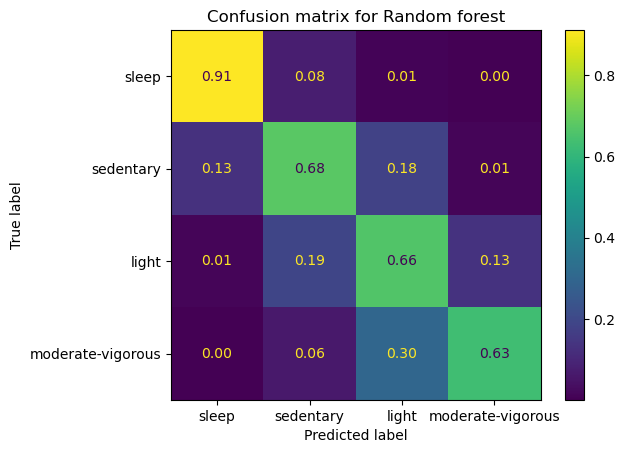

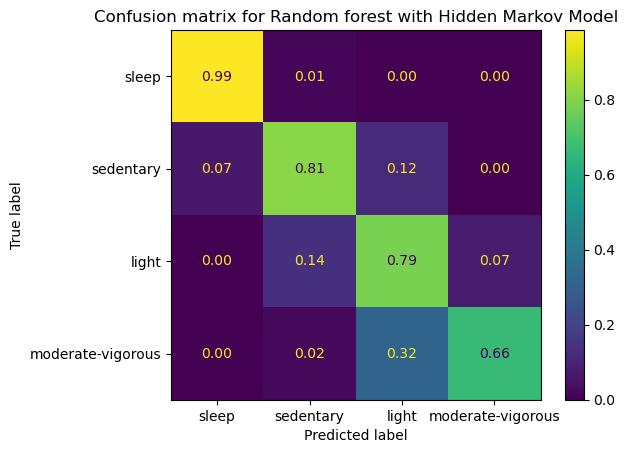

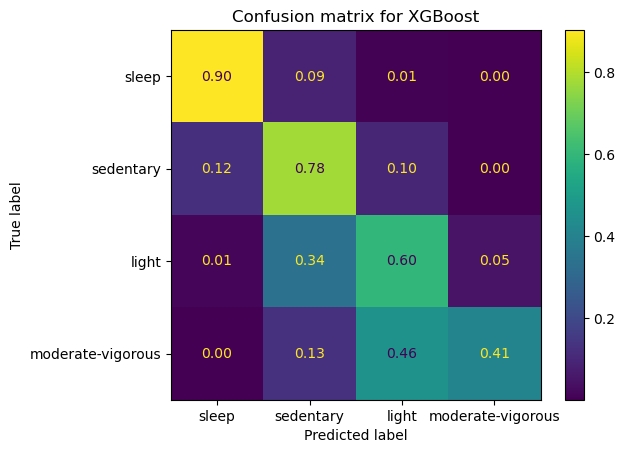

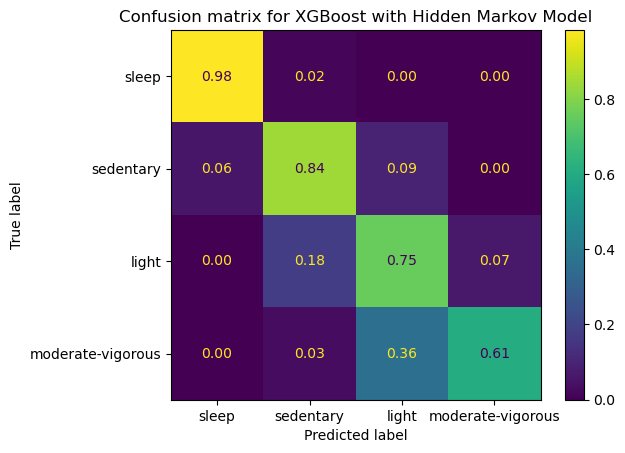

In [12]:

from sklearn.metrics import ConfusionMatrixDisplay
PAorder = ['sleep', 'sedentary','light','moderate-vigorous']
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_rf, normalize = 'true',labels = PAorder, values_format = '.2f')
plt.title('Confusion matrix for Random forest')
plt.show
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_rf_hmm, normalize = 'true', labels = PAorder, values_format = '.2f')
plt.title('Confusion matrix for Random forest with Hidden Markov Model')
plt.show()
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_xgb, normalize = 'true', labels = PAorder, values_format = '.2f')
plt.title('Confusion matrix for XGBoost')
plt.show()
ConfusionMatrixDisplay.from_predictions( y_test,y_pred_xgb_hmm, normalize = 'true', labels = PAorder, values_format = '.2f')
plt.title('Confusion matrix for XGBoost with Hidden Markov Model')
plt.show()

In [20]:
import seaborn as sns

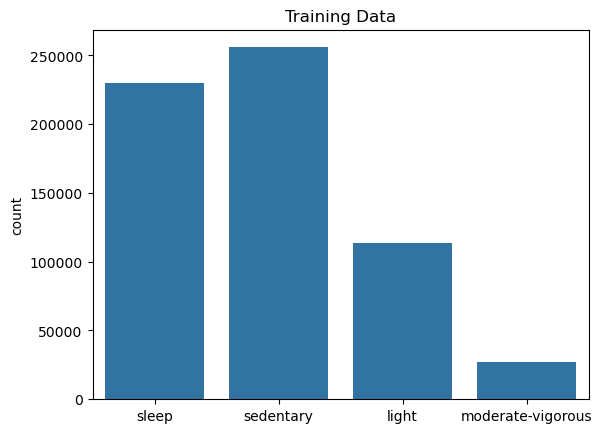

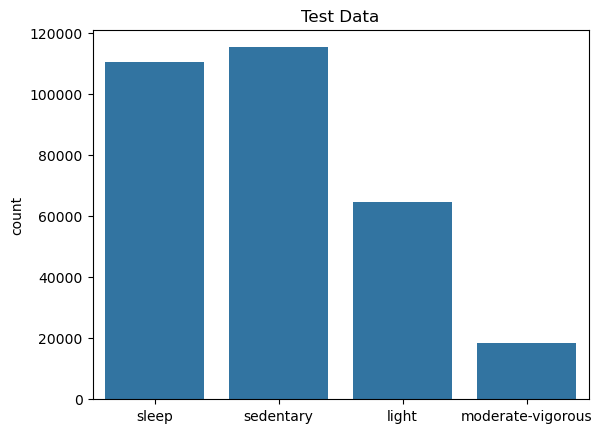

In [19]:
sns.countplot(x=y_train, order = PAorder)
plt.title('Training Data')
plt.show()
sns.countplot(x=y_test, order = PAorder)
plt.title('Test Data')
plt.show()

In [2]:
metadata = pd.read_csv("data\capture24\metadata.csv")
metadata.head(10)

,pid,age,sex
0,P001,38-52,F
1,P002,30-37,F
2,P003,30-37,F
3,P004,53+,F
4,P005,38-52,F
5,P006,18-29,F
6,P007,53+,M
7,P008,53+,F
8,P009,53+,F
9,P010,18-29,F


In [18]:
metadata[['age']].value_counts()

age  
18-29    43
30-37    37
38-52    37
53+      34
Name: count, dtype: int64

In [19]:
metadata[['sex']].value_counts()

sex
F      99
M      52
Name: count, dtype: int64